In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('../data/MF_simulation_DT_0.2.csv')

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [11]:
# df[df['batchID'] == 3]

In [4]:
df.shape

(6000, 24)

In [5]:
df.head()

,batchID,time(hr),process_phase,scenario,pH,biomass_conc(g/L),substrate_conc(g/L),product_conc(g/L),acetate_conc(g/L),viability,DO(%),kLa(hr1),gas_flow_rate(vvm),O2_uptake_rate(mmol/L/hr),agitation(rpm),ionic_strength(mol/L),TMP(cmHg),membrane_resistance(m1),flux(m/s),flux(LMH),power(W),filtration_time(hr),cumulative_eDNA(mg/L),cumulative_HCP(mg/L)
0,0,0.0,0,O2_limited,6.977670,0.118983,164.920421,0.001543,0.057413,0.953815,2.057918,1.6,0.041621,0.073459,80.000000,0.153670,0.0,0.0,0.0,0.0,0.294912,0.0,0.0,0.0
1,0,0.2,0,O2_limited,6.977044,0.122950,164.912083,0.001889,0.059069,0.952639,3.758095,1.6,0.041621,0.087404,80.554627,0.153904,0.0,0.0,0.0,0.0,0.301088,0.0,0.0,0.0
2,0,0.4,0,O2_limited,6.976423,0.129731,164.898592,0.002461,0.060714,0.951462,2.258035,1.6,0.041621,0.090318,80.554627,0.153127,0.0,0.0,0.0,0.0,0.301088,0.0,0.0,0.0
3,0,0.6,0,O2_limited,6.975807,0.134429,164.888825,0.002867,0.062350,0.950285,1.188626,1.6,0.041621,0.095300,80.554627,0.153658,0.0,0.0,0.0,0.0,0.301088,0.0,0.0,0.0
4,0,0.8,0,O2_limited,6.975195,0.137064,164.882762,0.003111,0.063976,0.949108,1.516383,1.6,0.041621,0.098750,80.554627,0.154410,0.0,0.0,0.0,0.0,0.301088,0.0,0.0,0.0


In [6]:
df.describe()

,batchID,time(hr),process_phase,pH,biomass_conc(g/L),substrate_conc(g/L),product_conc(g/L),acetate_conc(g/L),viability,DO(%),kLa(hr1),gas_flow_rate(vvm),O2_uptake_rate(mmol/L/hr),agitation(rpm),ionic_strength(mol/L),TMP(cmHg),membrane_resistance(m1),flux(m/s),flux(LMH),power(W),filtration_time(hr),cumulative_eDNA(mg/L),cumulative_HCP(mg/L)
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,19.500000,14.900000,0.333333,6.433325,37.708575,81.542300,3.450660,5.337454,0.771350,40.196292,511.590378,0.625228,29.741399,478.495867,0.126836,518.396974,2.453994e+16,9.951353e-07,3.582487,131.888018,1.633333,43.803610,640.008789
std,11.544358,8.660783,0.471444,0.412557,36.506433,71.155749,3.429890,4.670118,0.107088,41.313397,326.902498,0.395800,29.836020,284.138400,0.028814,1156.292719,6.816293e+16,2.508408e-06,9.030270,167.907715,2.848434,100.598675,1387.371066
min,0.000000,0.000000,0.000000,5.871598,0.113157,0.200000,0.001077,0.055083,0.511094,0.000000,1.600000,0.024059,0.050979,80.000000,0.079005,0.000000,0.000000e+00,0.000000e+00,0.000000,0.294912,0.000000,0.000000,0.000000
25%,9.750000,7.400000,0.000000,6.069994,1.514500,0.200000,0.126885,0.190804,0.687426,3.206541,1.600000,0.059696,1.268046,137.433528,0.093773,0.000000,0.000000e+00,0.000000e+00,0.000000,1.545204,0.000000,0.000000,0.000000
50%,19.500000,14.900000,0.000000,6.200121,26.961201,94.201675,2.222980,6.386824,0.784623,20.000000,626.628112,0.751319,20.206376,478.888293,0.138442,0.000000,0.000000e+00,0.000000e+00,0.000000,63.259411,0.000000,0.000000,0.000000
75%,29.250000,22.400000,1.000000,6.930149,75.300395,150.015652,6.908723,9.226834,0.855912,99.457083,800.000000,0.884464,55.354432,604.181947,0.151001,362.673027,1.473175e+15,2.000000e-06,7.200000,127.035680,2.400000,4.566687,91.854377
max,39.000000,29.800000,1.000000,6.978552,105.224059,177.857312,9.414274,15.793726,0.986953,100.000000,800.000000,1.302780,101.883184,1000.000000,0.171267,4500.000000,5.160061e+17,1.800000e-05,64.800000,576.050000,9.800000,638.676678,7983.458481


In [7]:
df['scenario'].value_counts()

scenario
late_harvest    1950
O2_limited      1650
shear_stress    1350
healthy         1050
Name: count, dtype: int64

In [8]:
scenario_summary = df.groupby('scenario').agg({
    'DO(%)': ['mean', 'min', 'max'],
    'biomass_conc(g/L)': 'max',
    'cumulative_eDNA(mg/L)': 'max'
})
print("\n scenario summary")
print(scenario_summary)


 scenario summary
                  DO(%)             biomass_conc(g/L) cumulative_eDNA(mg/L)
                   mean  min    max               max                   max
scenario                                                                   
O2_limited     8.210948  0.0   20.0         12.340637              9.339918
healthy       52.713507  0.0  100.0        105.224059            317.042247
late_harvest  51.960877  0.0  100.0        103.202311            308.416930
shear_stress  52.560587  0.0  100.0         97.682999            638.676678


In [10]:
growth_df = df[(df['process_phase'] == 0) & (df['substrate_conc(g/L)'] > 10)].copy()
growth_df['dX'] = growth_df.groupby('batchID')['biomass_conc(g/L)'].diff()
growth_df['dS'] = -growth_df.groupby('batchID')['substrate_conc(g/L)'].diff()
yield_stats = (growth_df['dX'] / growth_df['dS']).describe()

print("biomass yield (Y_xs) stats")
print(yield_stats)

biomass yield (Y_xs) stats
count    3190.000000
mean        0.335713
std         0.410504
min        -0.750000
25%         0.452476
50%         0.508862
75%         0.527605
max         0.535638
dtype: float64


In [11]:
phase_1 = df[df['process_phase'] == 1].copy()
trash_corr = phase_1[['cumulative_eDNA(mg/L)', 'cumulative_HCP(mg/L)', 'membrane_resistance(m1)']].corr()
print("\ntrash vs resistance correlation")
print(trash_corr)


trash vs resistance correlation
                         cumulative_eDNA(mg/L)  cumulative_HCP(mg/L)  \
cumulative_eDNA(mg/L)                 1.000000              0.982979   
cumulative_HCP(mg/L)                  0.982979              1.000000   
membrane_resistance(m1)               0.868574              0.905167   

                         membrane_resistance(m1)  
cumulative_eDNA(mg/L)                   0.868574  
cumulative_HCP(mg/L)                    0.905167  
membrane_resistance(m1)                 1.000000  


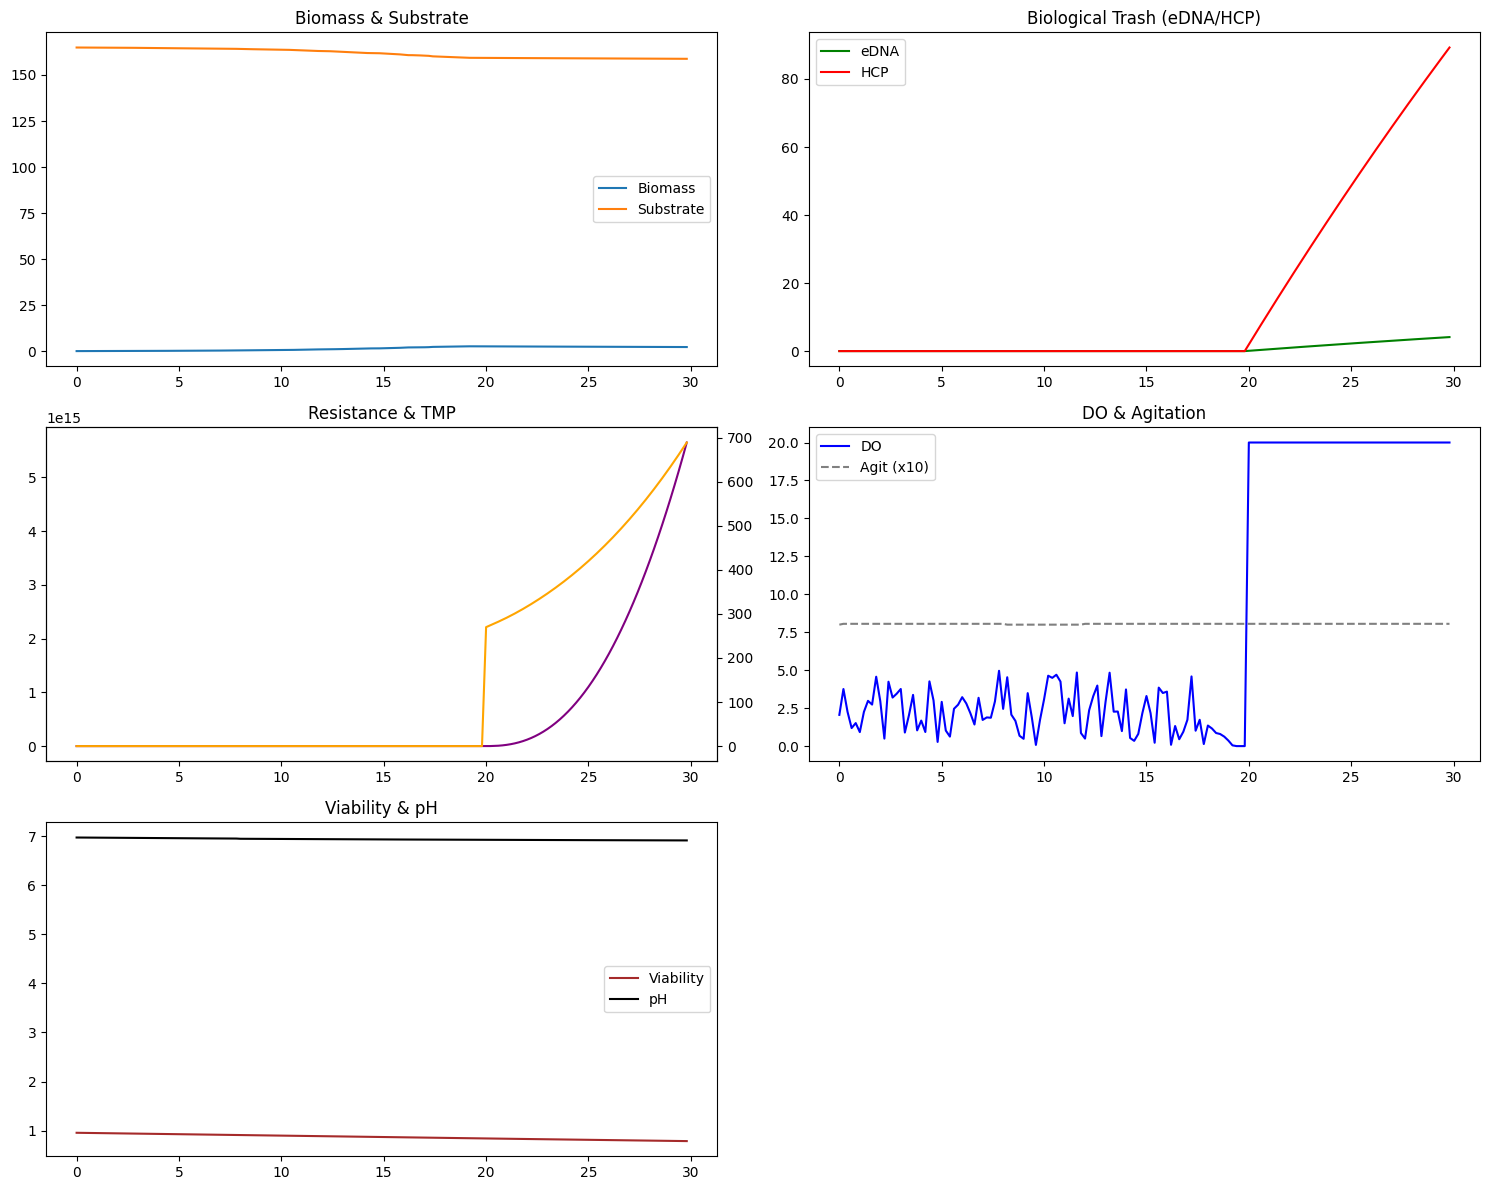

In [12]:
batch_0 = df[df['batchID'] == 0]

plt.figure(figsize=(15, 12))

#1: Biomass and Substrate
plt.subplot(3, 2, 1)
plt.plot(batch_0['time(hr)'], batch_0['biomass_conc(g/L)'], label='Biomass')
plt.plot(batch_0['time(hr)'], batch_0['substrate_conc(g/L)'], label='Substrate')
plt.title('Biomass & Substrate')
plt.legend()

#2: Trash Accumulation
plt.subplot(3, 2, 2)
plt.plot(batch_0['time(hr)'], batch_0['cumulative_eDNA(mg/L)'], label='eDNA', color='green')
plt.plot(batch_0['time(hr)'], batch_0['cumulative_HCP(mg/L)'], label='HCP', color='red')
plt.title('Biological Trash (eDNA/HCP)')
plt.legend()

#3: Resistance and TMP
plt.subplot(3, 2, 3)
plt.plot(batch_0['time(hr)'], batch_0['membrane_resistance(m1)'], label='Resistance', color='purple')
plt.twinx()
plt.plot(batch_0['time(hr)'], batch_0['TMP(cmHg)'], label='TMP', color='orange')
plt.title('Resistance & TMP')

#4: DO and Agitation
plt.subplot(3, 2, 4)
plt.plot(batch_0['time(hr)'], batch_0['DO(%)'], label='DO', color='blue')
plt.plot(batch_0['time(hr)'], batch_0['agitation(rpm)']/10, label='Agit (x10)', color='gray', linestyle='--')
plt.title('DO & Agitation')
plt.legend()

#5: Viability and pH
plt.subplot(3, 2, 5)
plt.plot(batch_0['time(hr)'], batch_0['viability'], label='Viability', color='brown')
plt.plot(batch_0['time(hr)'], batch_0['pH'], label='pH', color='black')
plt.title('Viability & pH')
plt.legend()

plt.tight_layout()

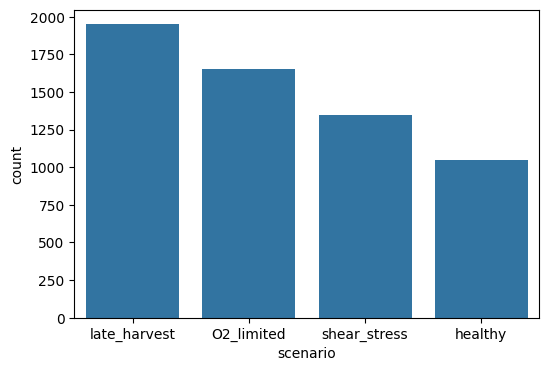

In [37]:
plt.figure(figsize=(6,4))
sns.barplot(df['scenario'].value_counts())
plt.show()

In [17]:
print(df.groupby('scenario')['batchID'].nunique())

scenario
O2_limited      11
healthy          7
late_harvest    13
shear_stress     9
Name: batchID, dtype: int64


In [22]:
columns = df.columns.tolist()
print(columns)

['batchID', 'time(hr)', 'process_phase', 'scenario', 'pH', 'biomass_conc(g/L)', 'substrate_conc(g/L)', 'product_conc(g/L)', 'acetate_conc(g/L)', 'viability', 'DO(%)', 'kLa(hr1)', 'gas_flow_rate(vvm)', 'O2_uptake_rate(mmol/L/hr)', 'agitation(rpm)', 'ionic_strength(mol/L)', 'TMP(cmHg)', 'membrane_resistance(m1)', 'flux(m/s)', 'flux(LMH)', 'power(W)', 'filtration_time(hr)', 'cumulative_eDNA(mg/L)', 'cumulative_HCP(mg/L)']


<Axes: xlabel='process_phase', ylabel='count'>

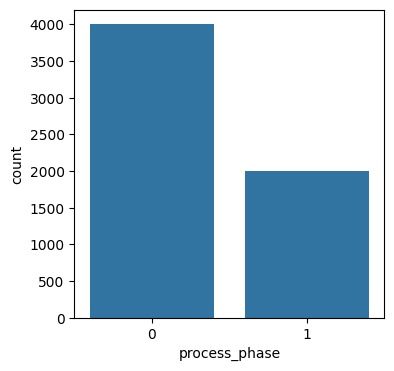

In [ ]:
plt.figure(figsize=(4,4))
sns.barplot(df['process_phase'].value_counts())
plt.show()

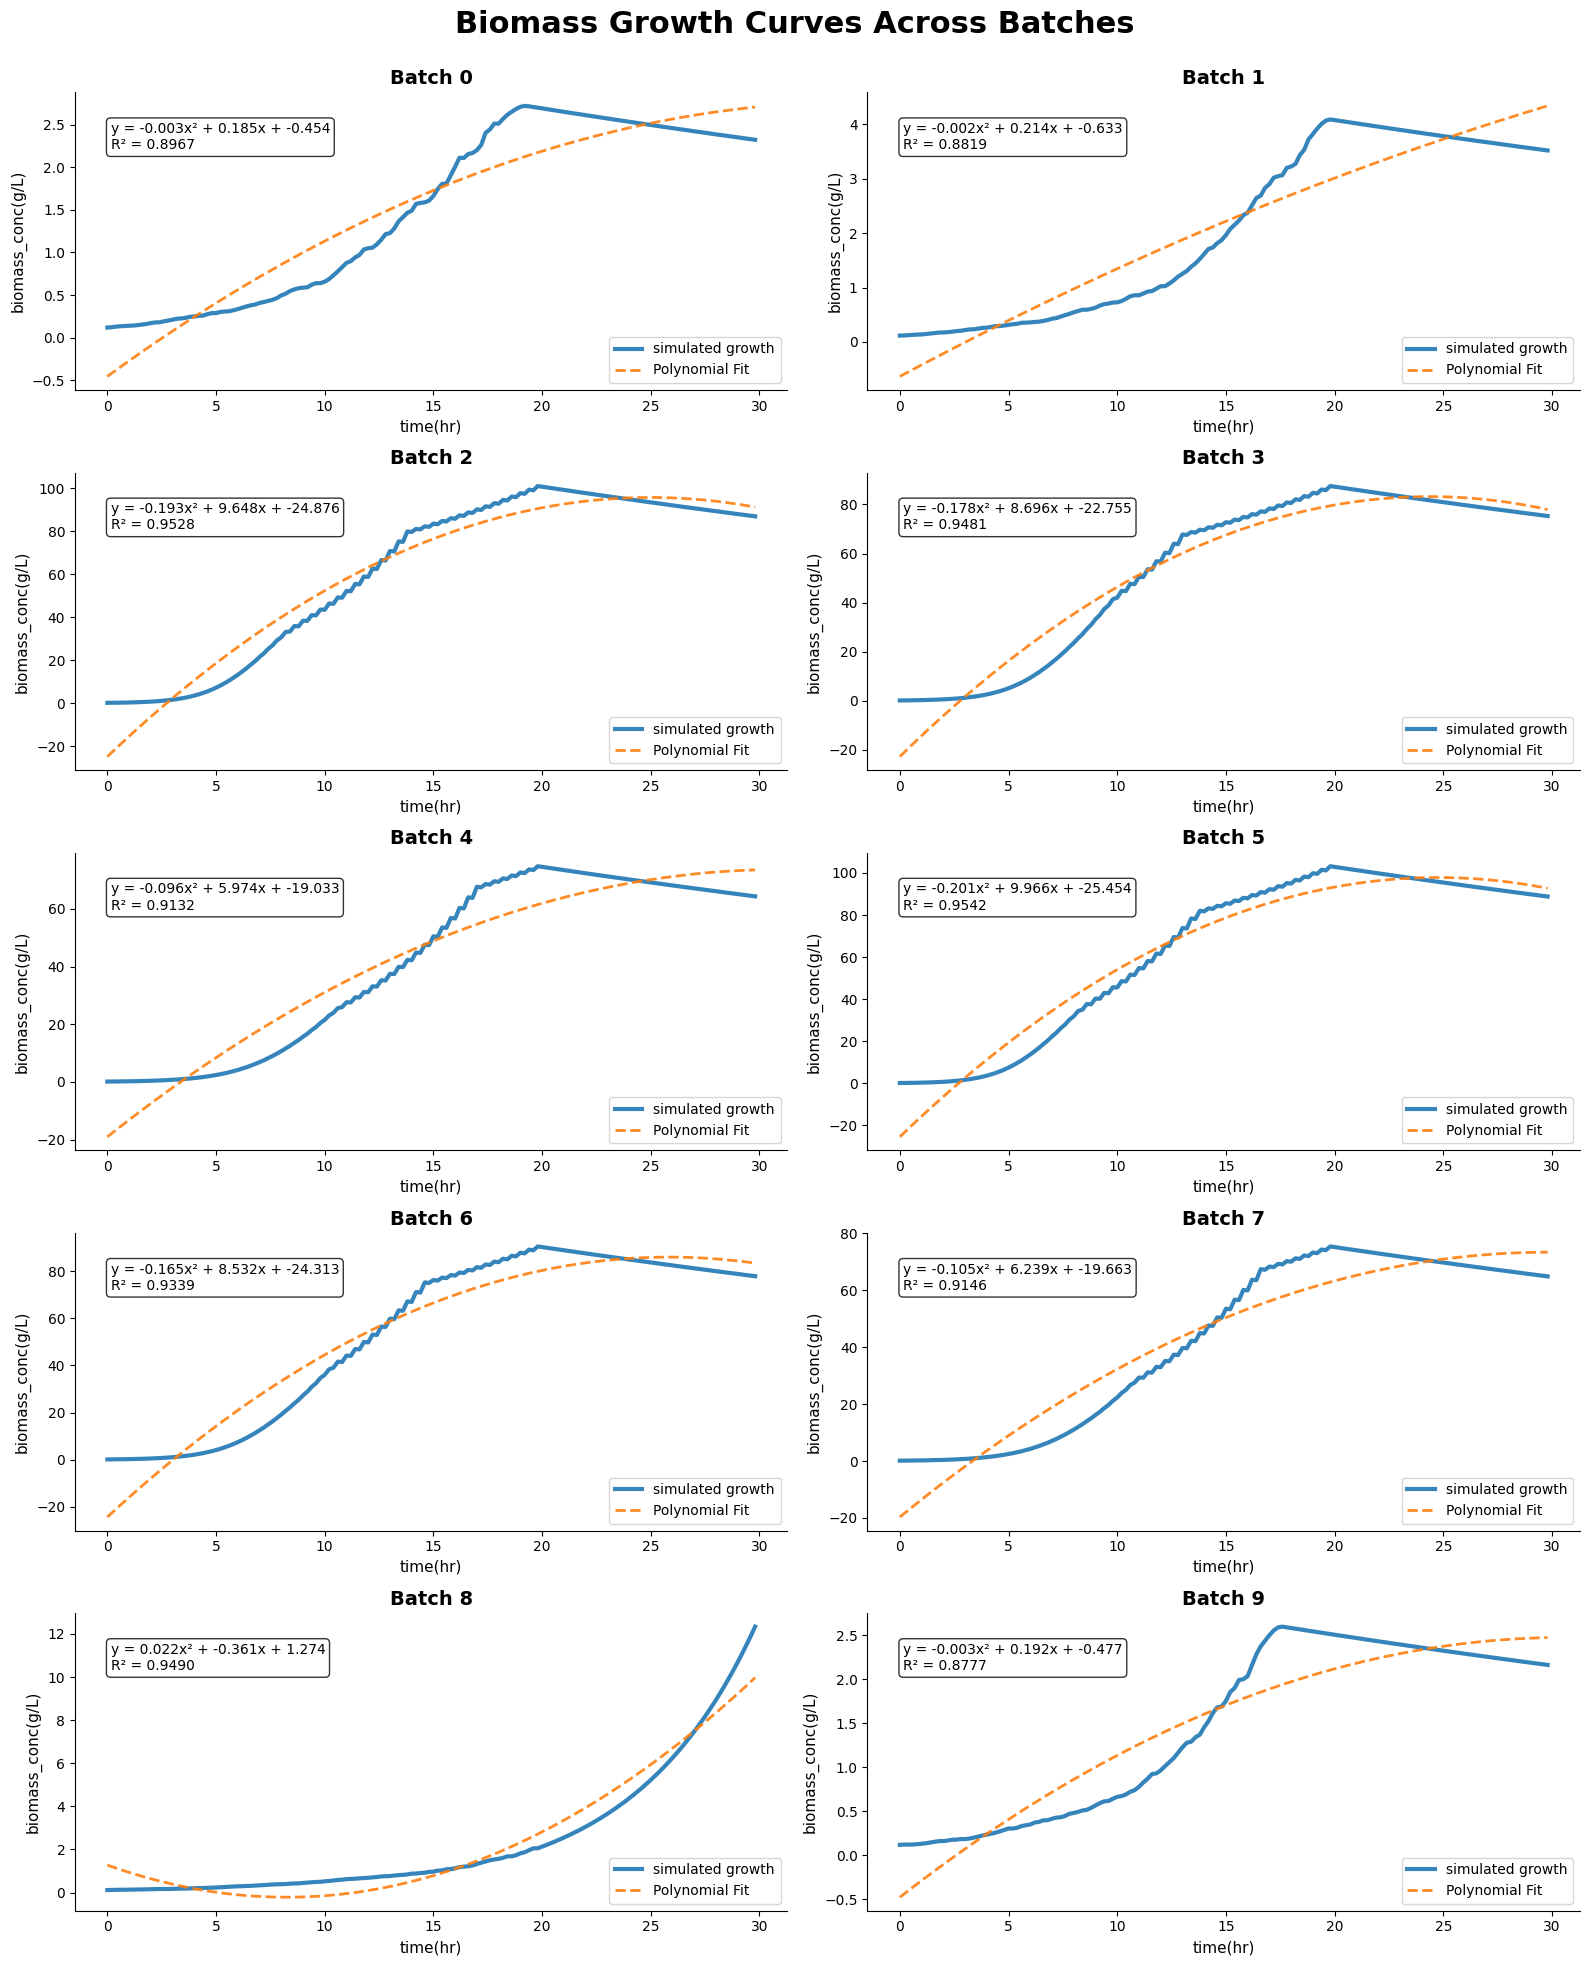

In [15]:
from sklearn.metrics import r2_score
selected_batches = df['batchID'].unique()[:10]

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(16, 20),
    facecolor='white'
)
axes = axes.flatten()

for idx, batch in enumerate(selected_batches):

    batch_df = df[df['batchID'] == batch]
    x = batch_df['time(hr)'].values
    y = batch_df['biomass_conc(g/L)'].values

    coeffs = np.polyfit(x, y, 2)
    poly_eq = np.poly1d(coeffs)
    y_fit = poly_eq(x)

    r2 = r2_score(y, y_fit)

    axes[idx].plot(
        x,
        y,
        linewidth=3,
        alpha=0.9,
        label='simulated growth'
    )

    axes[idx].plot(
        x,
        y_fit,
        linestyle='--',
        linewidth=2,
        alpha=0.9,
        label='Polynomial Fit'
    )

    equation = (
        f"y = {coeffs[0]:.3f}x² "
        f"+ {coeffs[1]:.3f}x "
        f"+ {coeffs[2]:.3f}\n"
        f"R² = {r2:.4f}"
    )

    axes[idx].text(
        0.05,
        0.90,

        equation,
        transform=axes[idx].transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='black',
            boxstyle='round'
        )
    )

    axes[idx].set_title(f'Batch {batch}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('time(hr)', fontsize=11)
    axes[idx].set_ylabel('biomass_conc(g/L)', fontsize=11)
    axes[idx].legend()
    axes[idx].grid(False)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

fig.suptitle('Biomass Growth Curves Across Batches', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

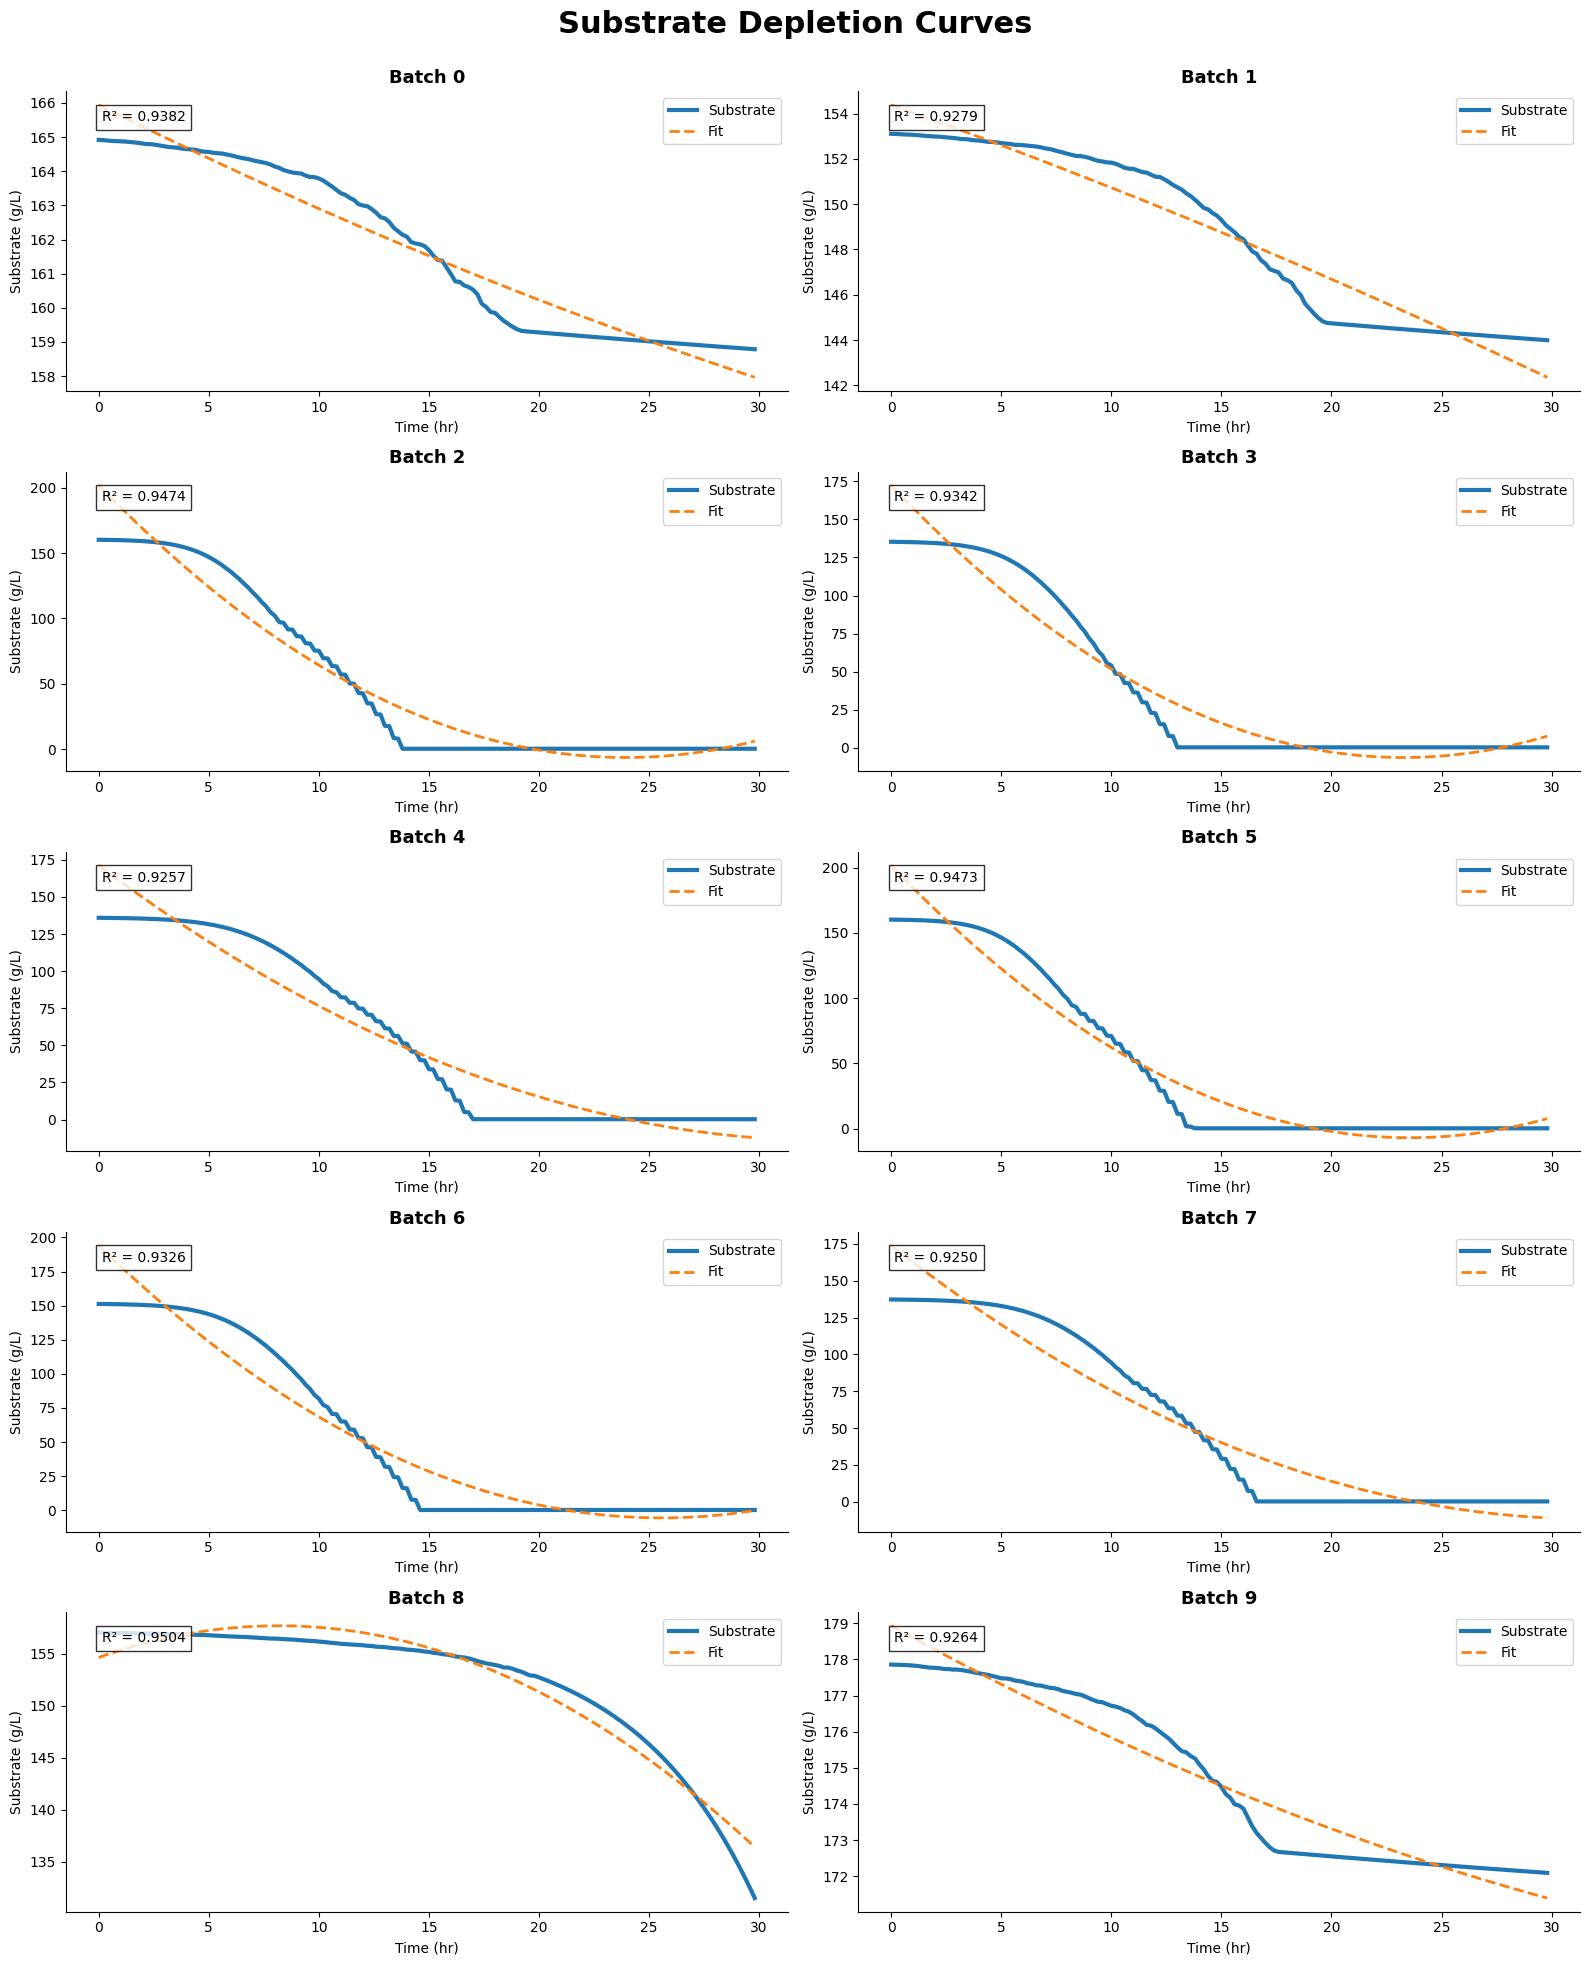

In [16]:
selected_batches = df['batchID'].unique()[:10]

fig, axes = plt.subplots(
    5, 2,
    figsize=(16,20),
    facecolor='white'
)
axes = axes.flatten()

for idx, batch in enumerate(selected_batches):

    batch_df = df[df['batchID'] == batch]
    x = batch_df['time(hr)'].values
    y = batch_df['substrate_conc(g/L)'].values

    coeffs = np.polyfit(x, y, 2)
    poly = np.poly1d(coeffs)
    y_fit = poly(x)
    r2 = r2_score(y, y_fit)


    axes[idx].plot(
        x,
        y,
        linewidth=3,
        label='Substrate'
    )

    axes[idx].plot(
        x,
        y_fit,
        linestyle='--',
        linewidth=2,
        label='Fit'
    )

    eq = f"R² = {r2:.4f}"

    axes[idx].text(
        0.05,
        0.90,
        eq,
        transform=axes[idx].transAxes,
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            alpha=0.8
        )
    )

    axes[idx].set_title(
        f'Batch {batch}',
        fontsize=13,
        fontweight='bold'
    )

    axes[idx].set_xlabel('Time (hr)')
    axes[idx].set_ylabel('Substrate (g/L)')
    axes[idx].legend()
    axes[idx].grid(False)

    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

fig.suptitle(
    'Substrate Depletion Curves',
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout(rect=[0,0,1,0.98])
plt.show()

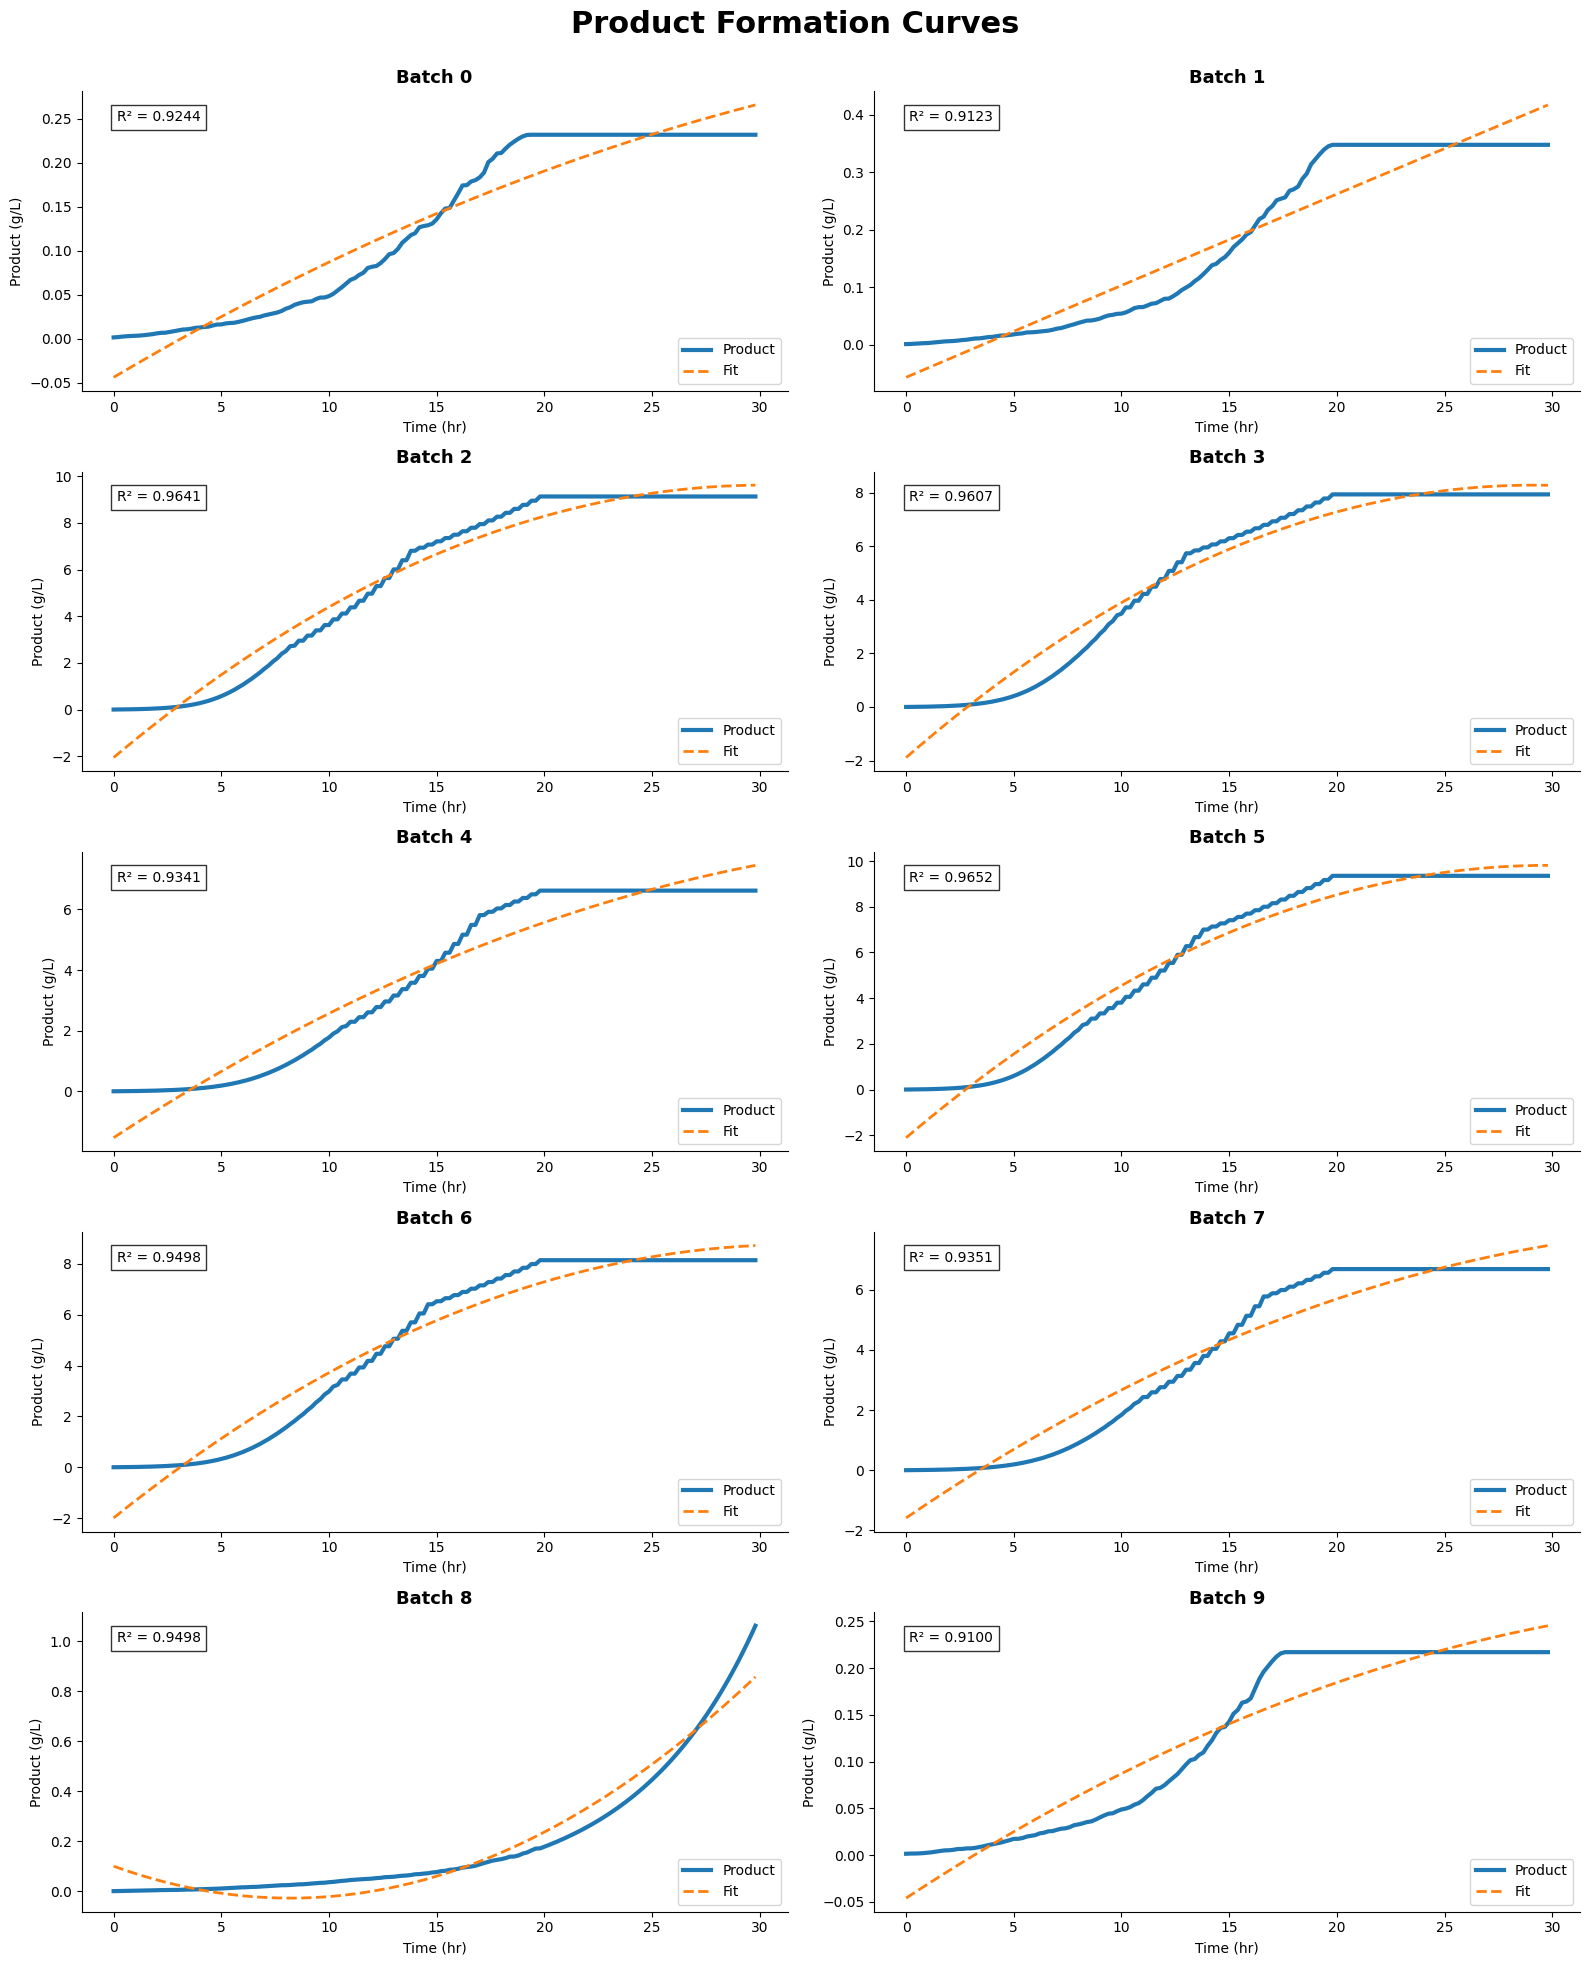

In [17]:
fig, axes = plt.subplots(
    5, 2,
    figsize=(16,20),
    facecolor='white'
)
axes = axes.flatten()

for idx, batch in enumerate(selected_batches):

    batch_df = df[df['batchID'] == batch]
    x = batch_df['time(hr)'].values
    y = batch_df['product_conc(g/L)'].values

    coeffs = np.polyfit(x, y, 2)
    poly = np.poly1d(coeffs)
    y_fit = poly(x)
    r2 = r2_score(y, y_fit)

    axes[idx].plot(
        x,
        y,
        linewidth=3,
        label='Product'
    )

    axes[idx].plot(
        x,
        y_fit,
        linestyle='--',
        linewidth=2,
        label='Fit'
    )

    axes[idx].text(
        0.05,
        0.90,
        f"R² = {r2:.4f}",
        transform=axes[idx].transAxes,
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            alpha=0.8
        )
    )

    axes[idx].set_title(
        f'Batch {batch}',
        fontsize=13,
        fontweight='bold'
    )

    axes[idx].set_xlabel('Time (hr)')
    axes[idx].set_ylabel('Product (g/L)')
    axes[idx].legend()
    axes[idx].grid(False)

    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

fig.suptitle(
    'Product Formation Curves',
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout(
    rect=[0,0,1,0.98]
)
plt.show()

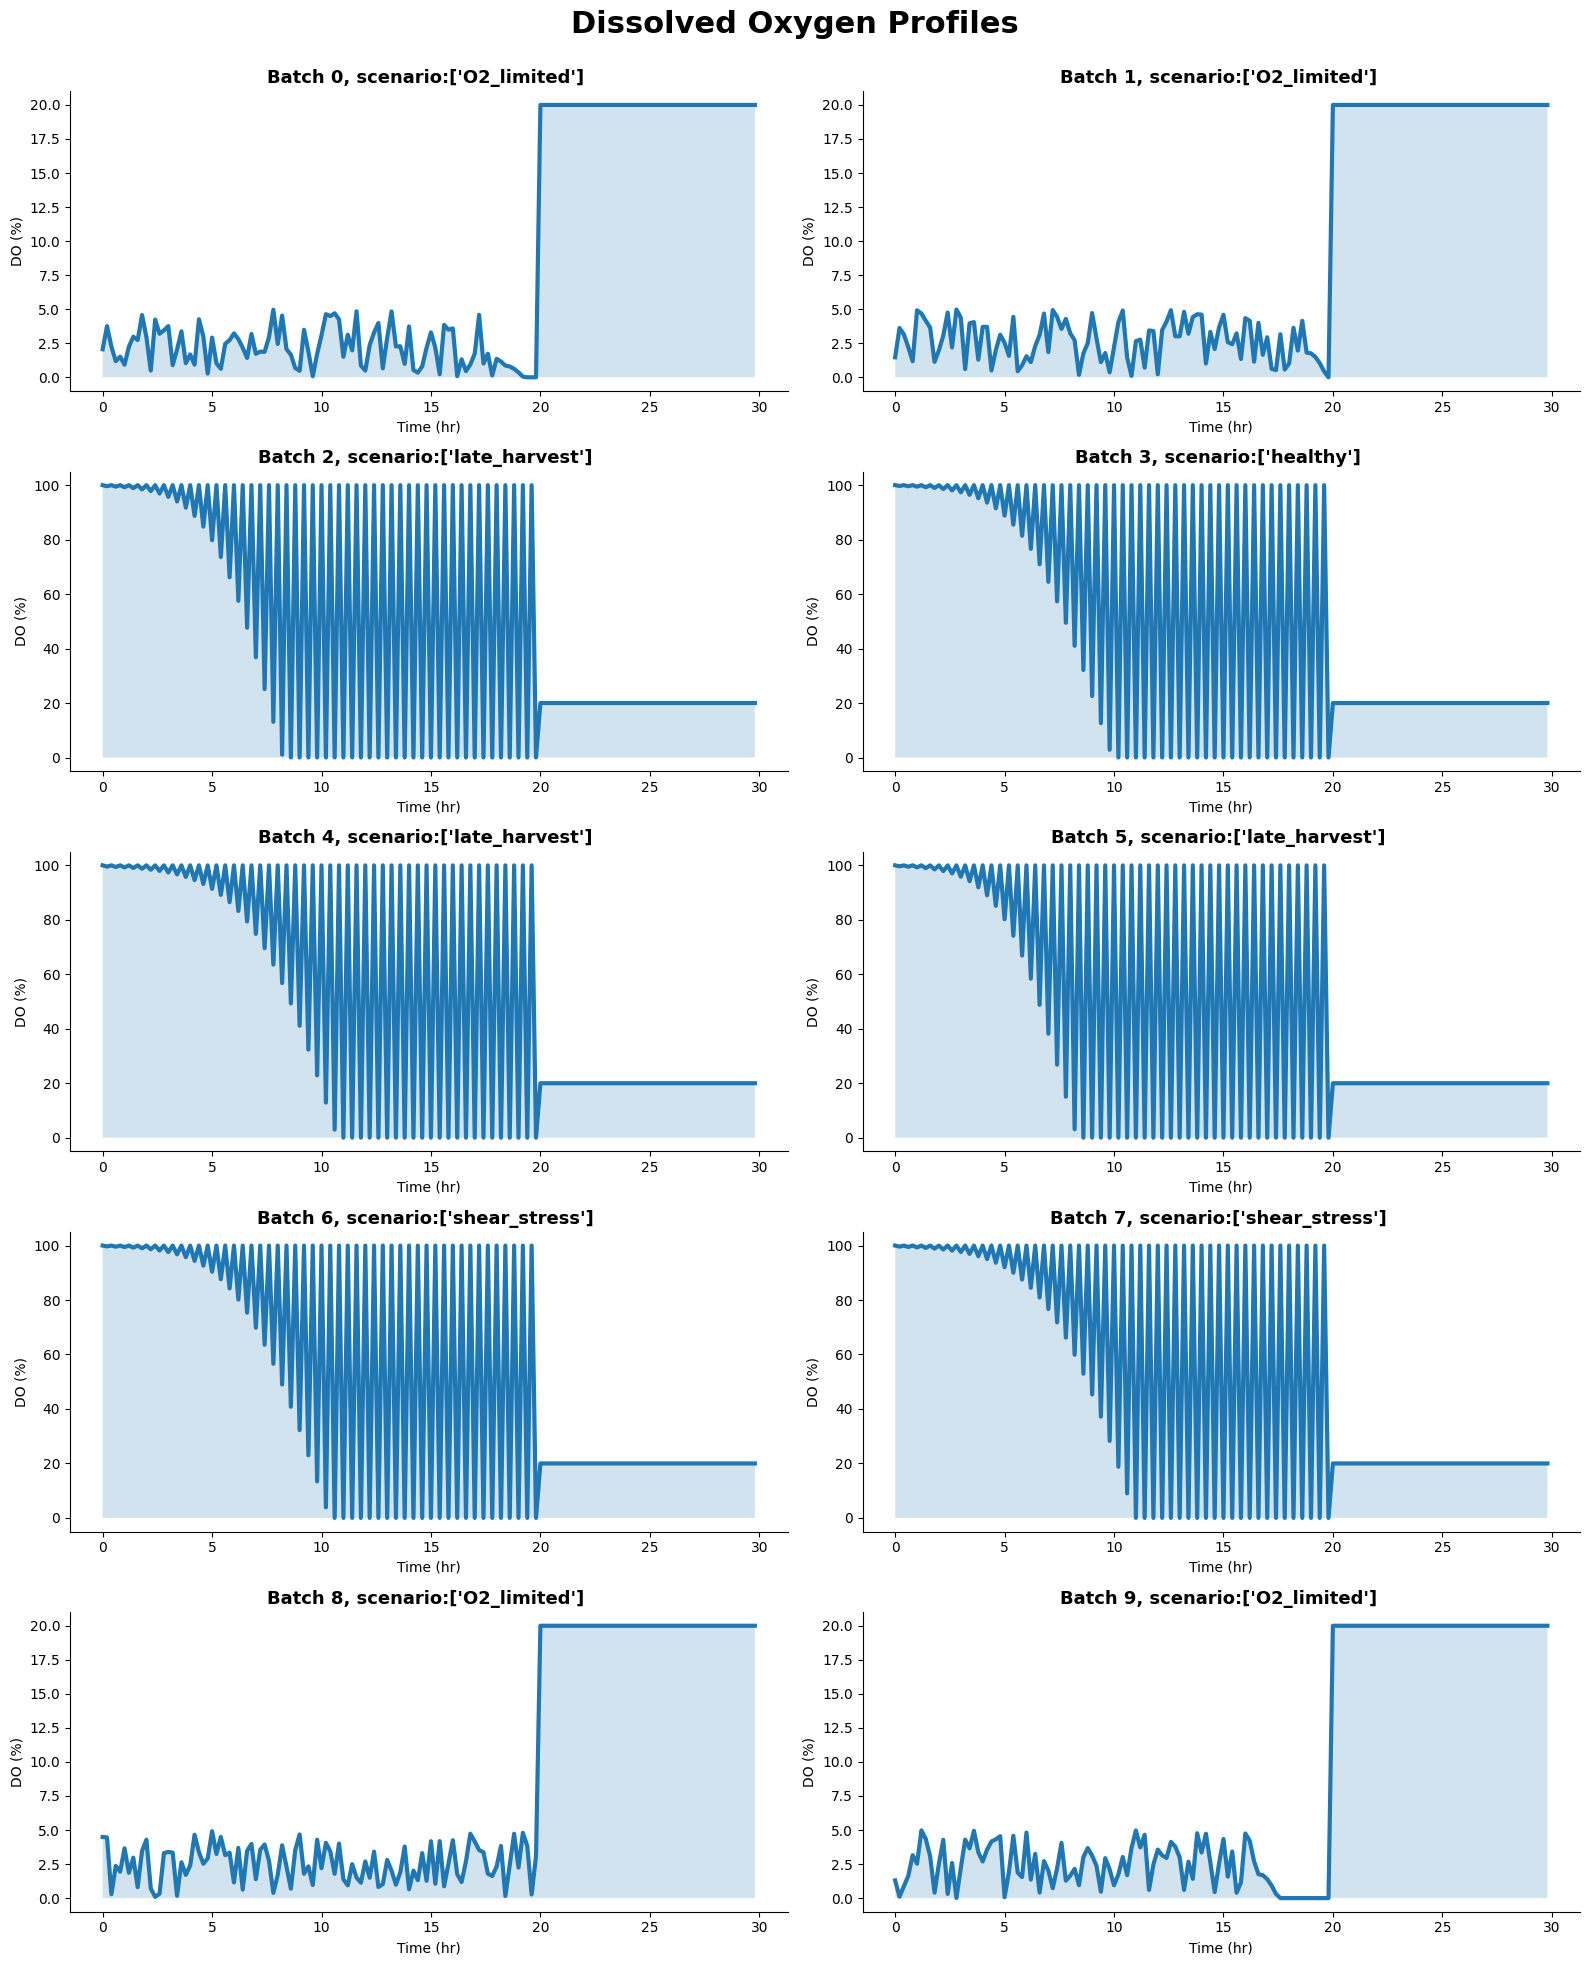

In [18]:
fig, axes = plt.subplots(
    5, 2,
    figsize=(16,20),
    facecolor='white'
)
axes = axes.flatten()

for idx, batch in enumerate(selected_batches):

    batch_df = df[df['batchID'] == batch]
    x = batch_df['time(hr)'].values
    y = batch_df['DO(%)'].values

    axes[idx].plot(
        x,
        y,
        linewidth=3
    )

    axes[idx].fill_between(
        x,
        y,
        alpha=0.2
    )

    axes[idx].set_title(
        f'Batch {batch}, scenario:{batch_df['scenario'].unique()} ',
        fontsize=13,
        fontweight='bold'
    )

    axes[idx].set_xlabel('Time (hr)')
    axes[idx].set_ylabel('DO (%)')
    axes[idx].grid(False)

    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

fig.suptitle(
    'Dissolved Oxygen Profiles',
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout(rect=[0,0,1,0.98])
plt.show()

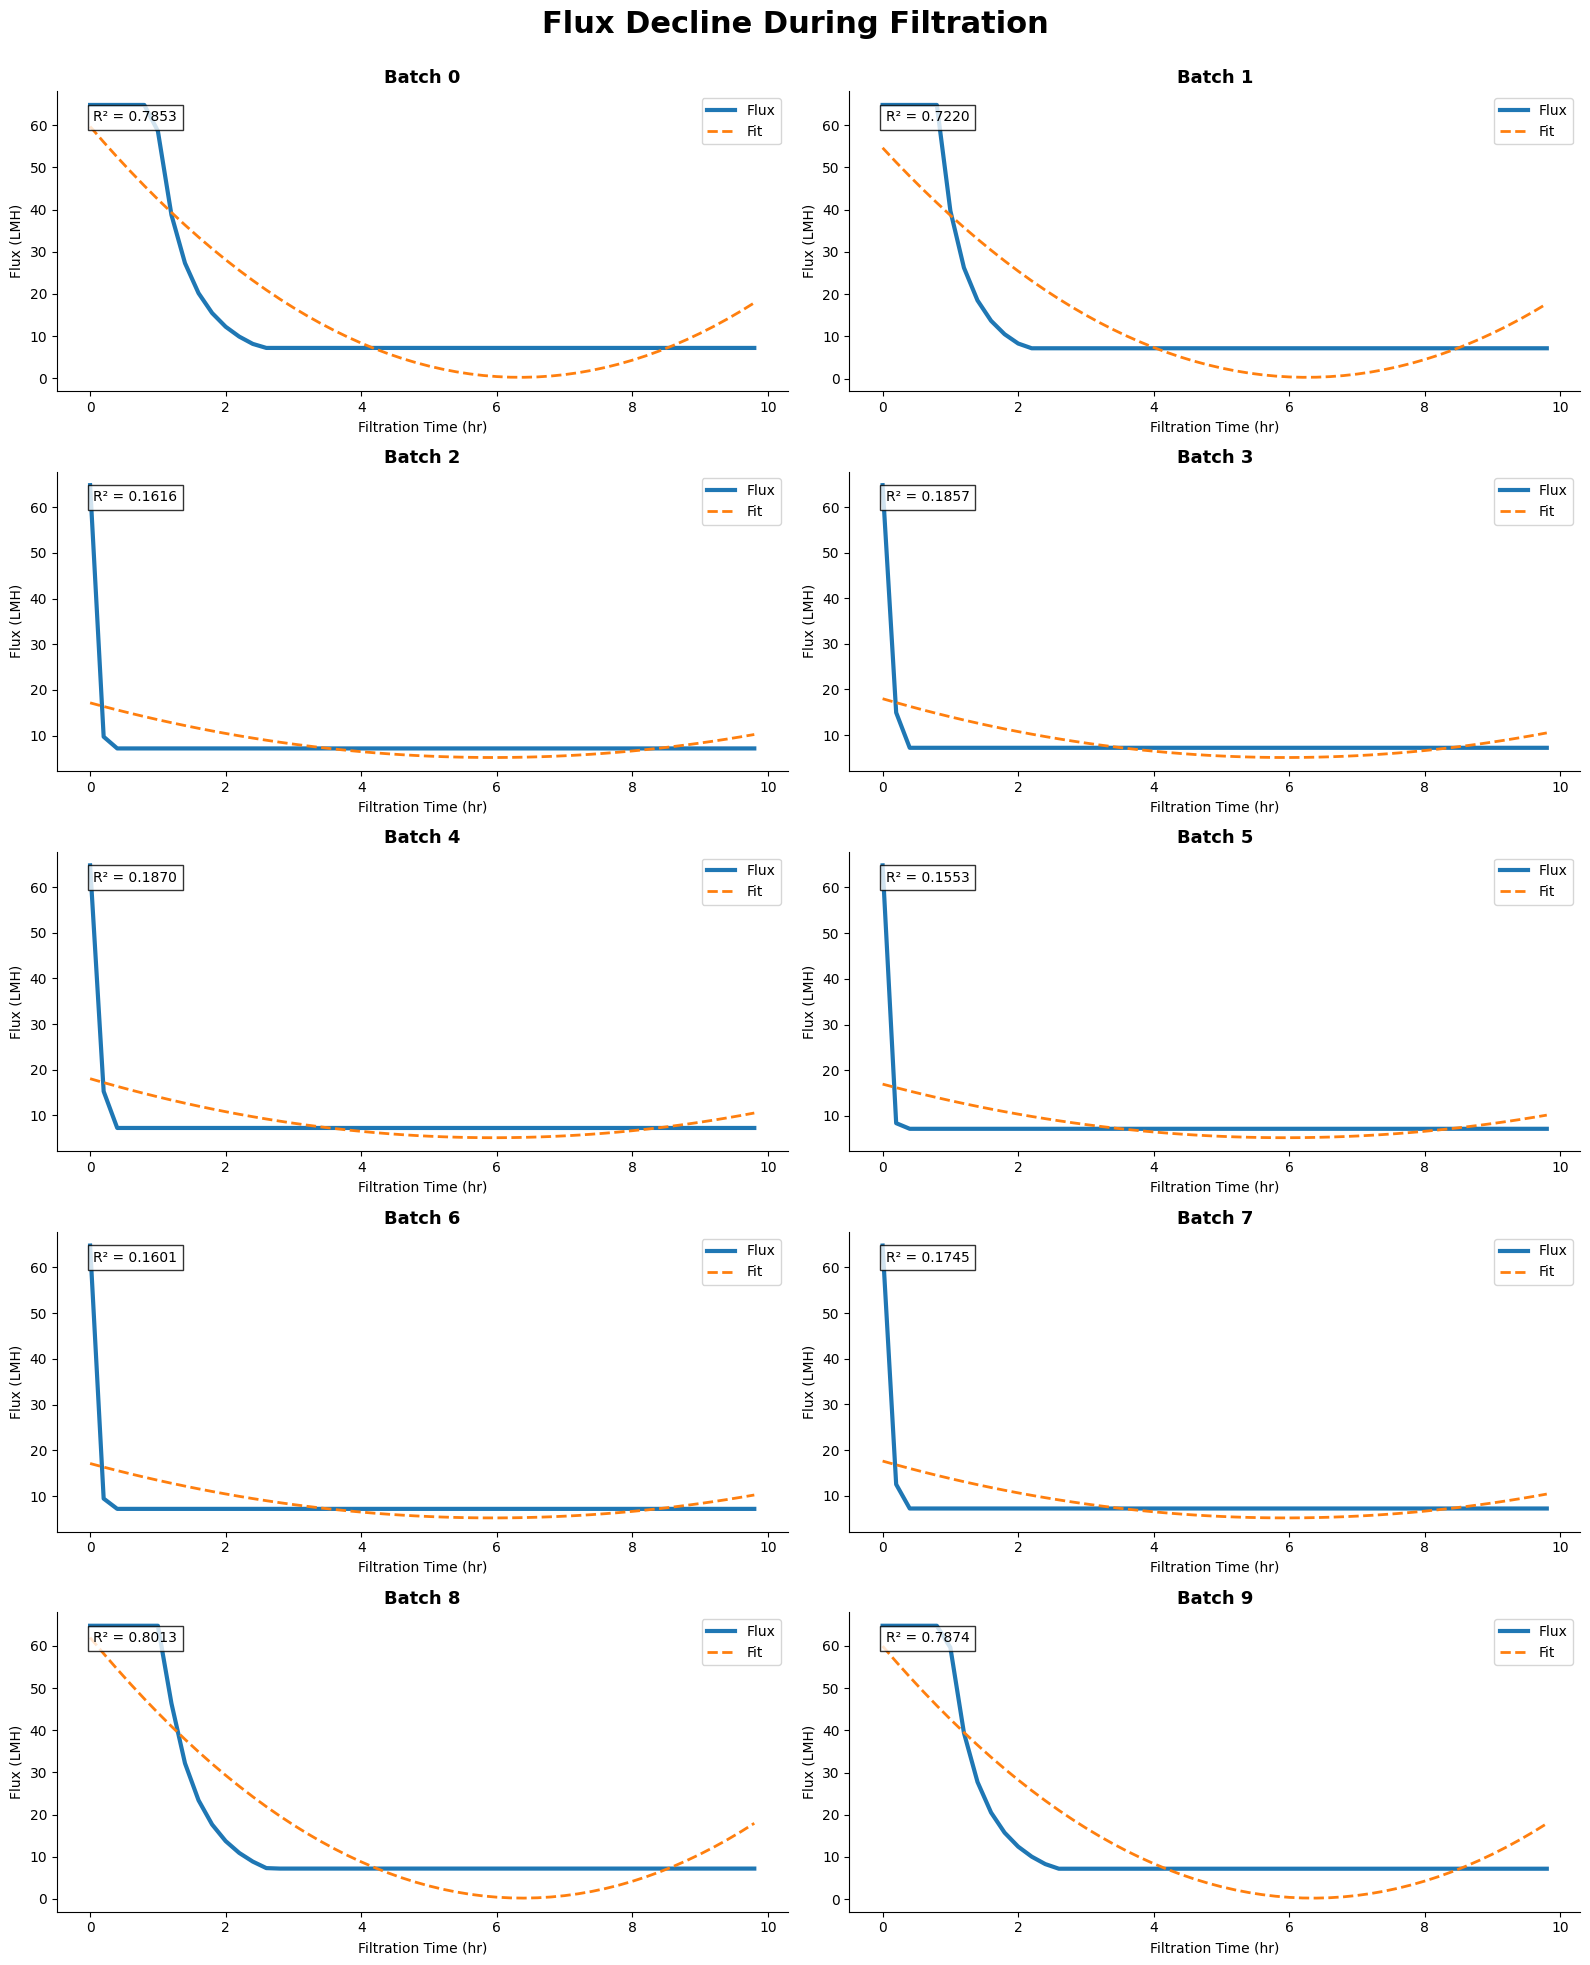

In [19]:
filtration_df = df[
    df['process_phase'] == 1
]

fig, axes = plt.subplots(
    5, 2,
    figsize=(16,20),
    facecolor='white'
)
axes = axes.flatten()

for idx, batch in enumerate(selected_batches):

    batch_df = filtration_df[filtration_df['batchID'] == batch]
    x = batch_df['filtration_time(hr)'].values
    y = batch_df['flux(LMH)'].values

    coeffs = np.polyfit(x, y, 2)
    poly = np.poly1d(coeffs)
    y_fit = poly(x)
    r2 = r2_score(y, y_fit)

    axes[idx].plot(
        x,
        y,
        linewidth=3,
        label='Flux'
    )

    axes[idx].plot(
        x,
        y_fit,
        linestyle='--',
        linewidth=2,
        label='Fit'
    )

    axes[idx].text(
        0.05,
        0.90,
        f"R² = {r2:.4f}",
        transform=axes[idx].transAxes,
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            alpha=0.8
        )
    )

    axes[idx].set_title(
        f'Batch {batch}',
        fontsize=13,
        fontweight='bold'
    )

    axes[idx].set_xlabel('Filtration Time (hr)')
    axes[idx].set_ylabel('Flux (LMH)')
    axes[idx].legend()
    axes[idx].grid(False)

    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

fig.suptitle(
    'Flux Decline During Filtration',
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout(rect=[0,0,1,0.98])
plt.show()

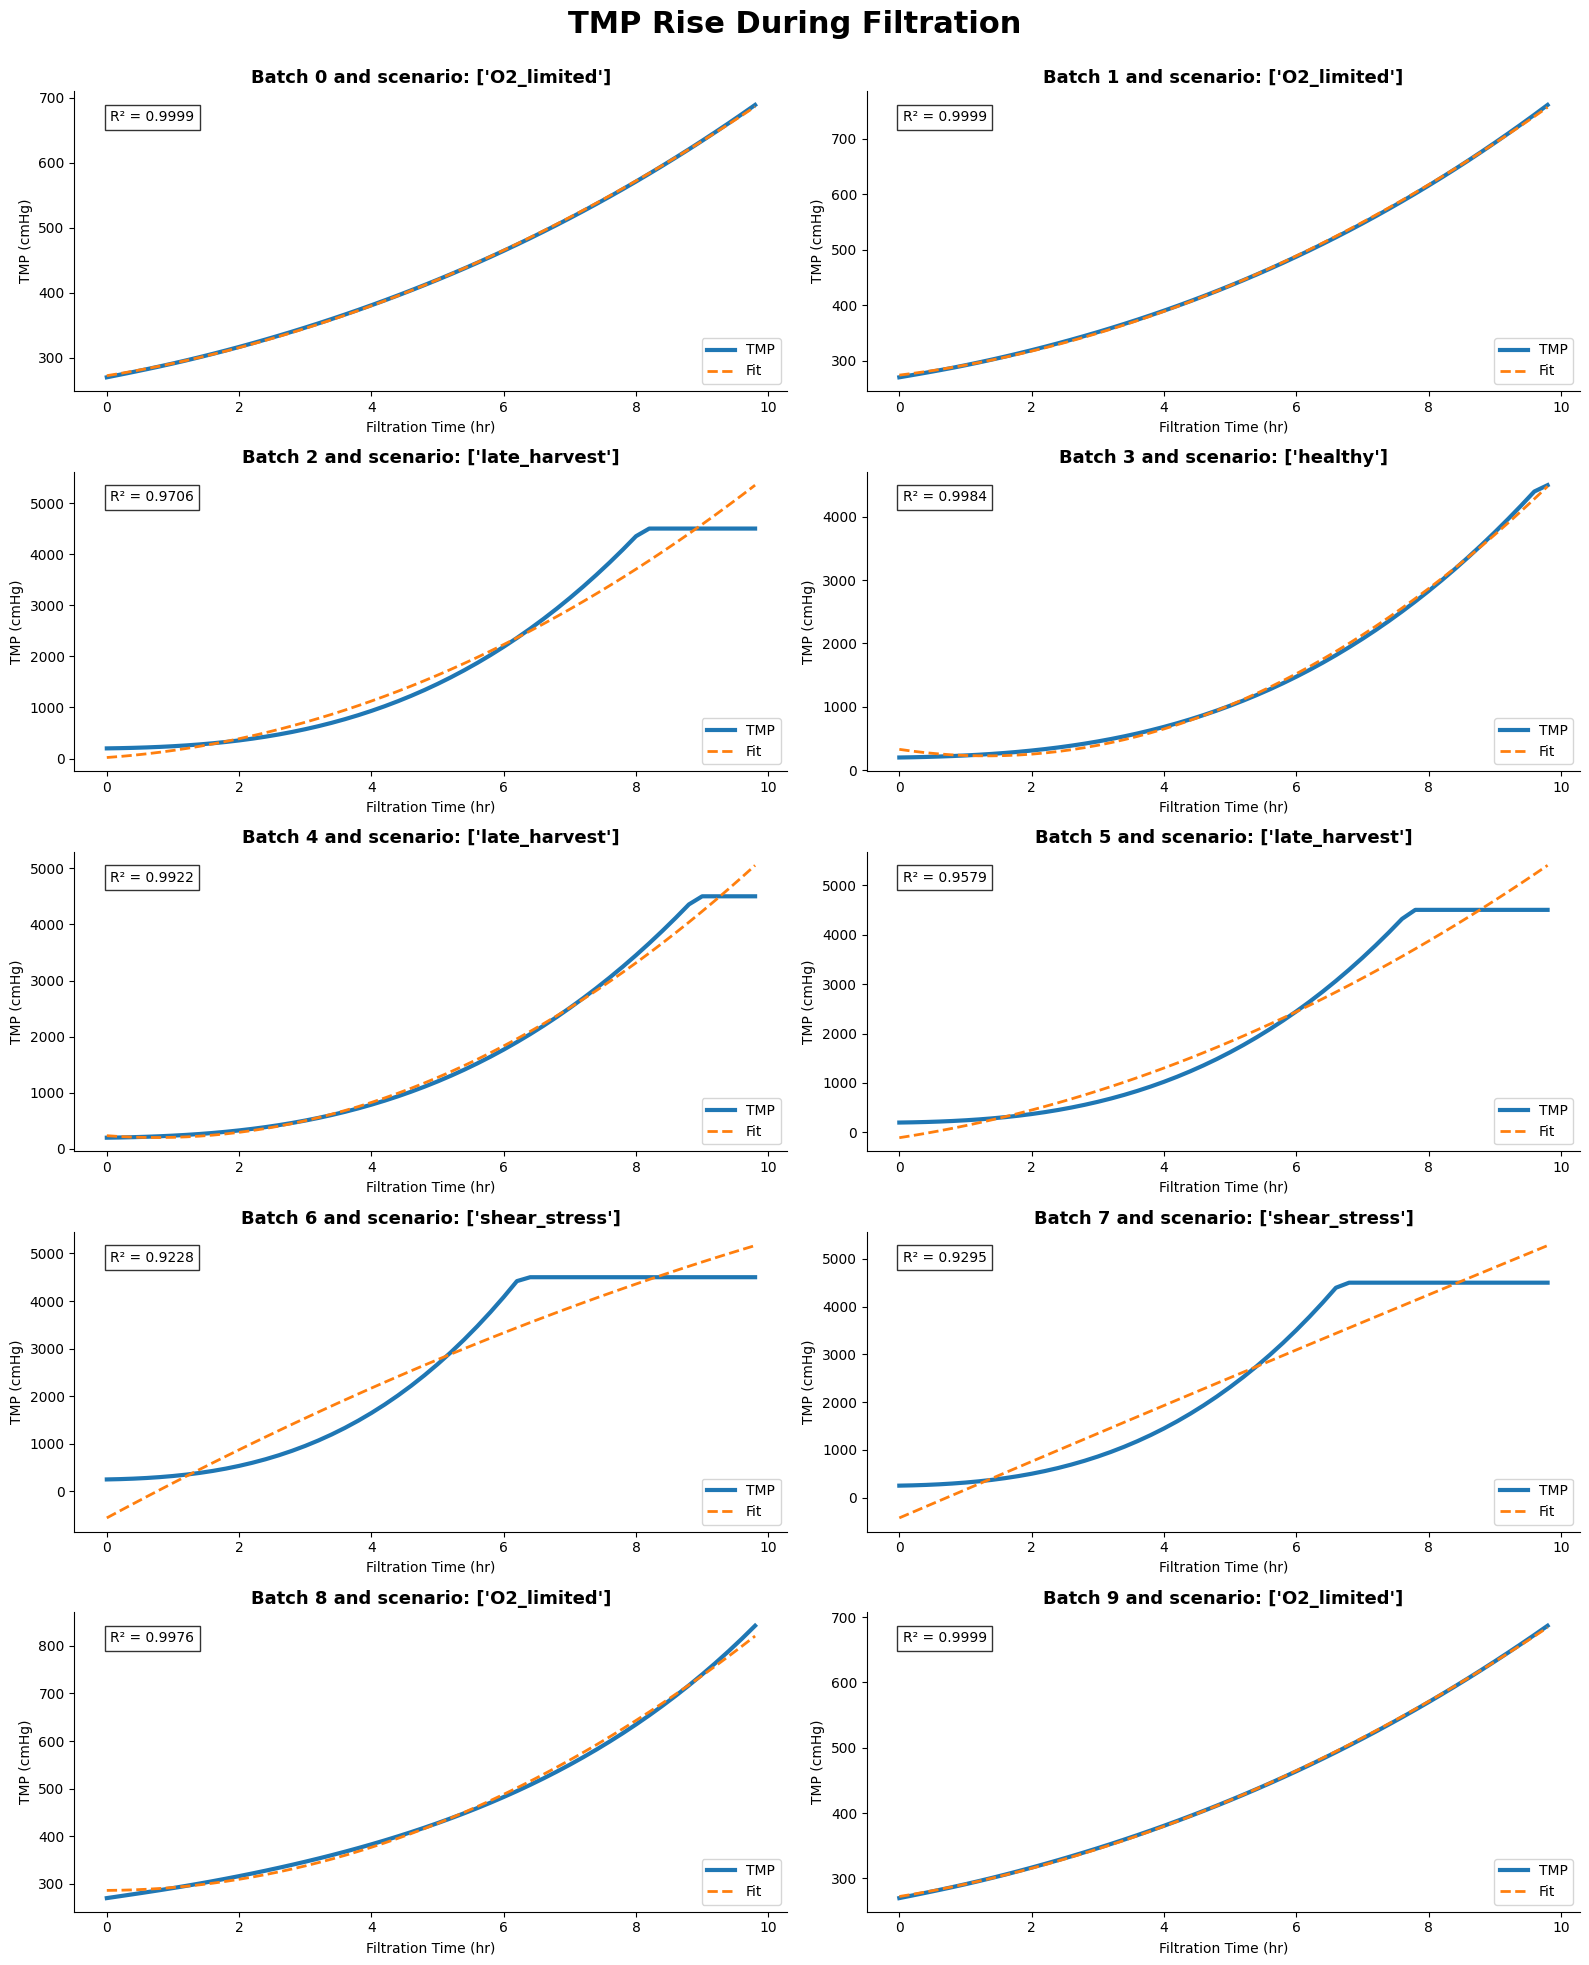

In [20]:
fig, axes = plt.subplots(
    5, 2,
    figsize=(16,20),
    facecolor='white'
)
axes = axes.flatten()

for idx, batch in enumerate(selected_batches):

    batch_df = filtration_df[filtration_df['batchID'] == batch]
    x = batch_df['filtration_time(hr)'].values
    y = batch_df['TMP(cmHg)'].values

    coeffs = np.polyfit(x, y, 2)
    poly = np.poly1d(coeffs)
    y_fit = poly(x)
    r2 = r2_score(y, y_fit)

    axes[idx].plot(
        x,
        y,
        linewidth=3,
        label='TMP'
    )

    axes[idx].plot(
        x,
        y_fit,
        linestyle='--',
        linewidth=2,
        label='Fit'
    )

    axes[idx].text(
        0.05,
        0.90,
        f"R² = {r2:.4f}",
        transform=axes[idx].transAxes,
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            alpha=0.8
        )
    )

    axes[idx].set_title(
        f'Batch {batch} and scenario: {batch_df['scenario'].unique()}',
        fontsize=13,
        fontweight='bold'
    )

    axes[idx].set_xlabel('Filtration Time (hr)')
    axes[idx].set_ylabel('TMP (cmHg)')
    axes[idx].legend()
    axes[idx].grid(False)

    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

fig.suptitle(
    'TMP Rise During Filtration',
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout(rect=[0,0,1,0.98])
plt.show()

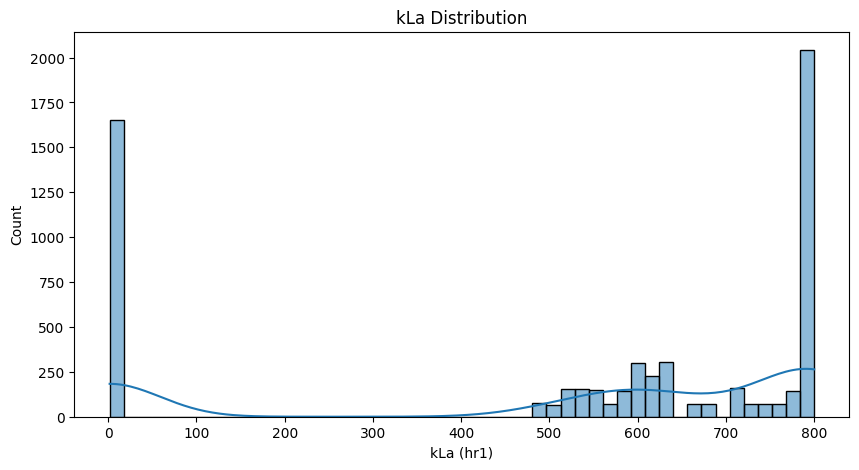

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['kLa(hr1)'],
    bins=50,
    kde=True
)

plt.title("kLa Distribution")
plt.xlabel("kLa (hr1)")
plt.show()

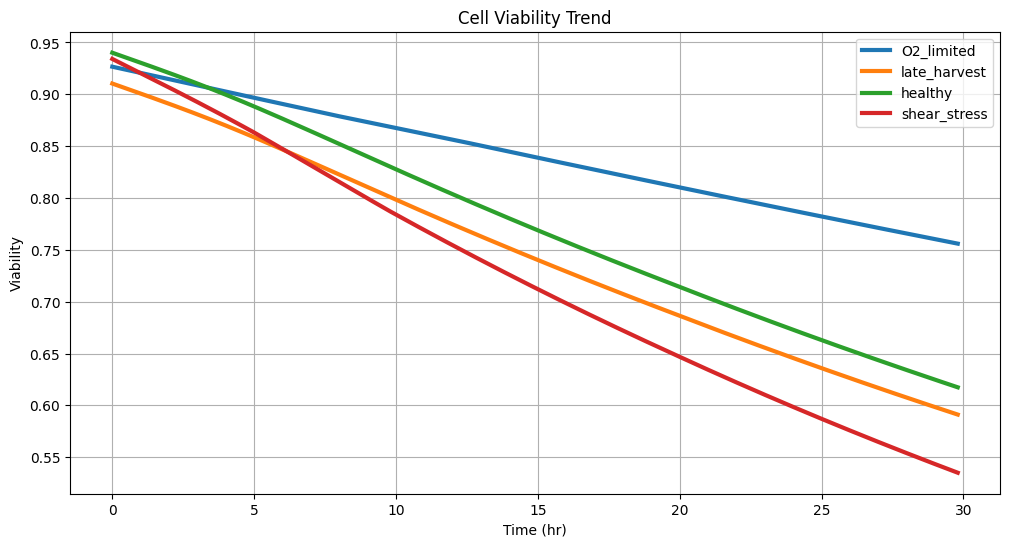

In [22]:
plt.figure(figsize=(12,6))

for scenario in df['scenario'].unique():

    temp = df[df['scenario'] == scenario]

    mean_viability = (
        temp.groupby('time(hr)')['viability']
        .mean()
    )

    plt.plot(
        mean_viability.index,
        mean_viability.values,
        label=scenario,
        linewidth=3
    )

plt.title("Cell Viability Trend")
plt.xlabel("Time (hr)")
plt.ylabel("Viability")
plt.legend()
plt.grid(True)
plt.show()

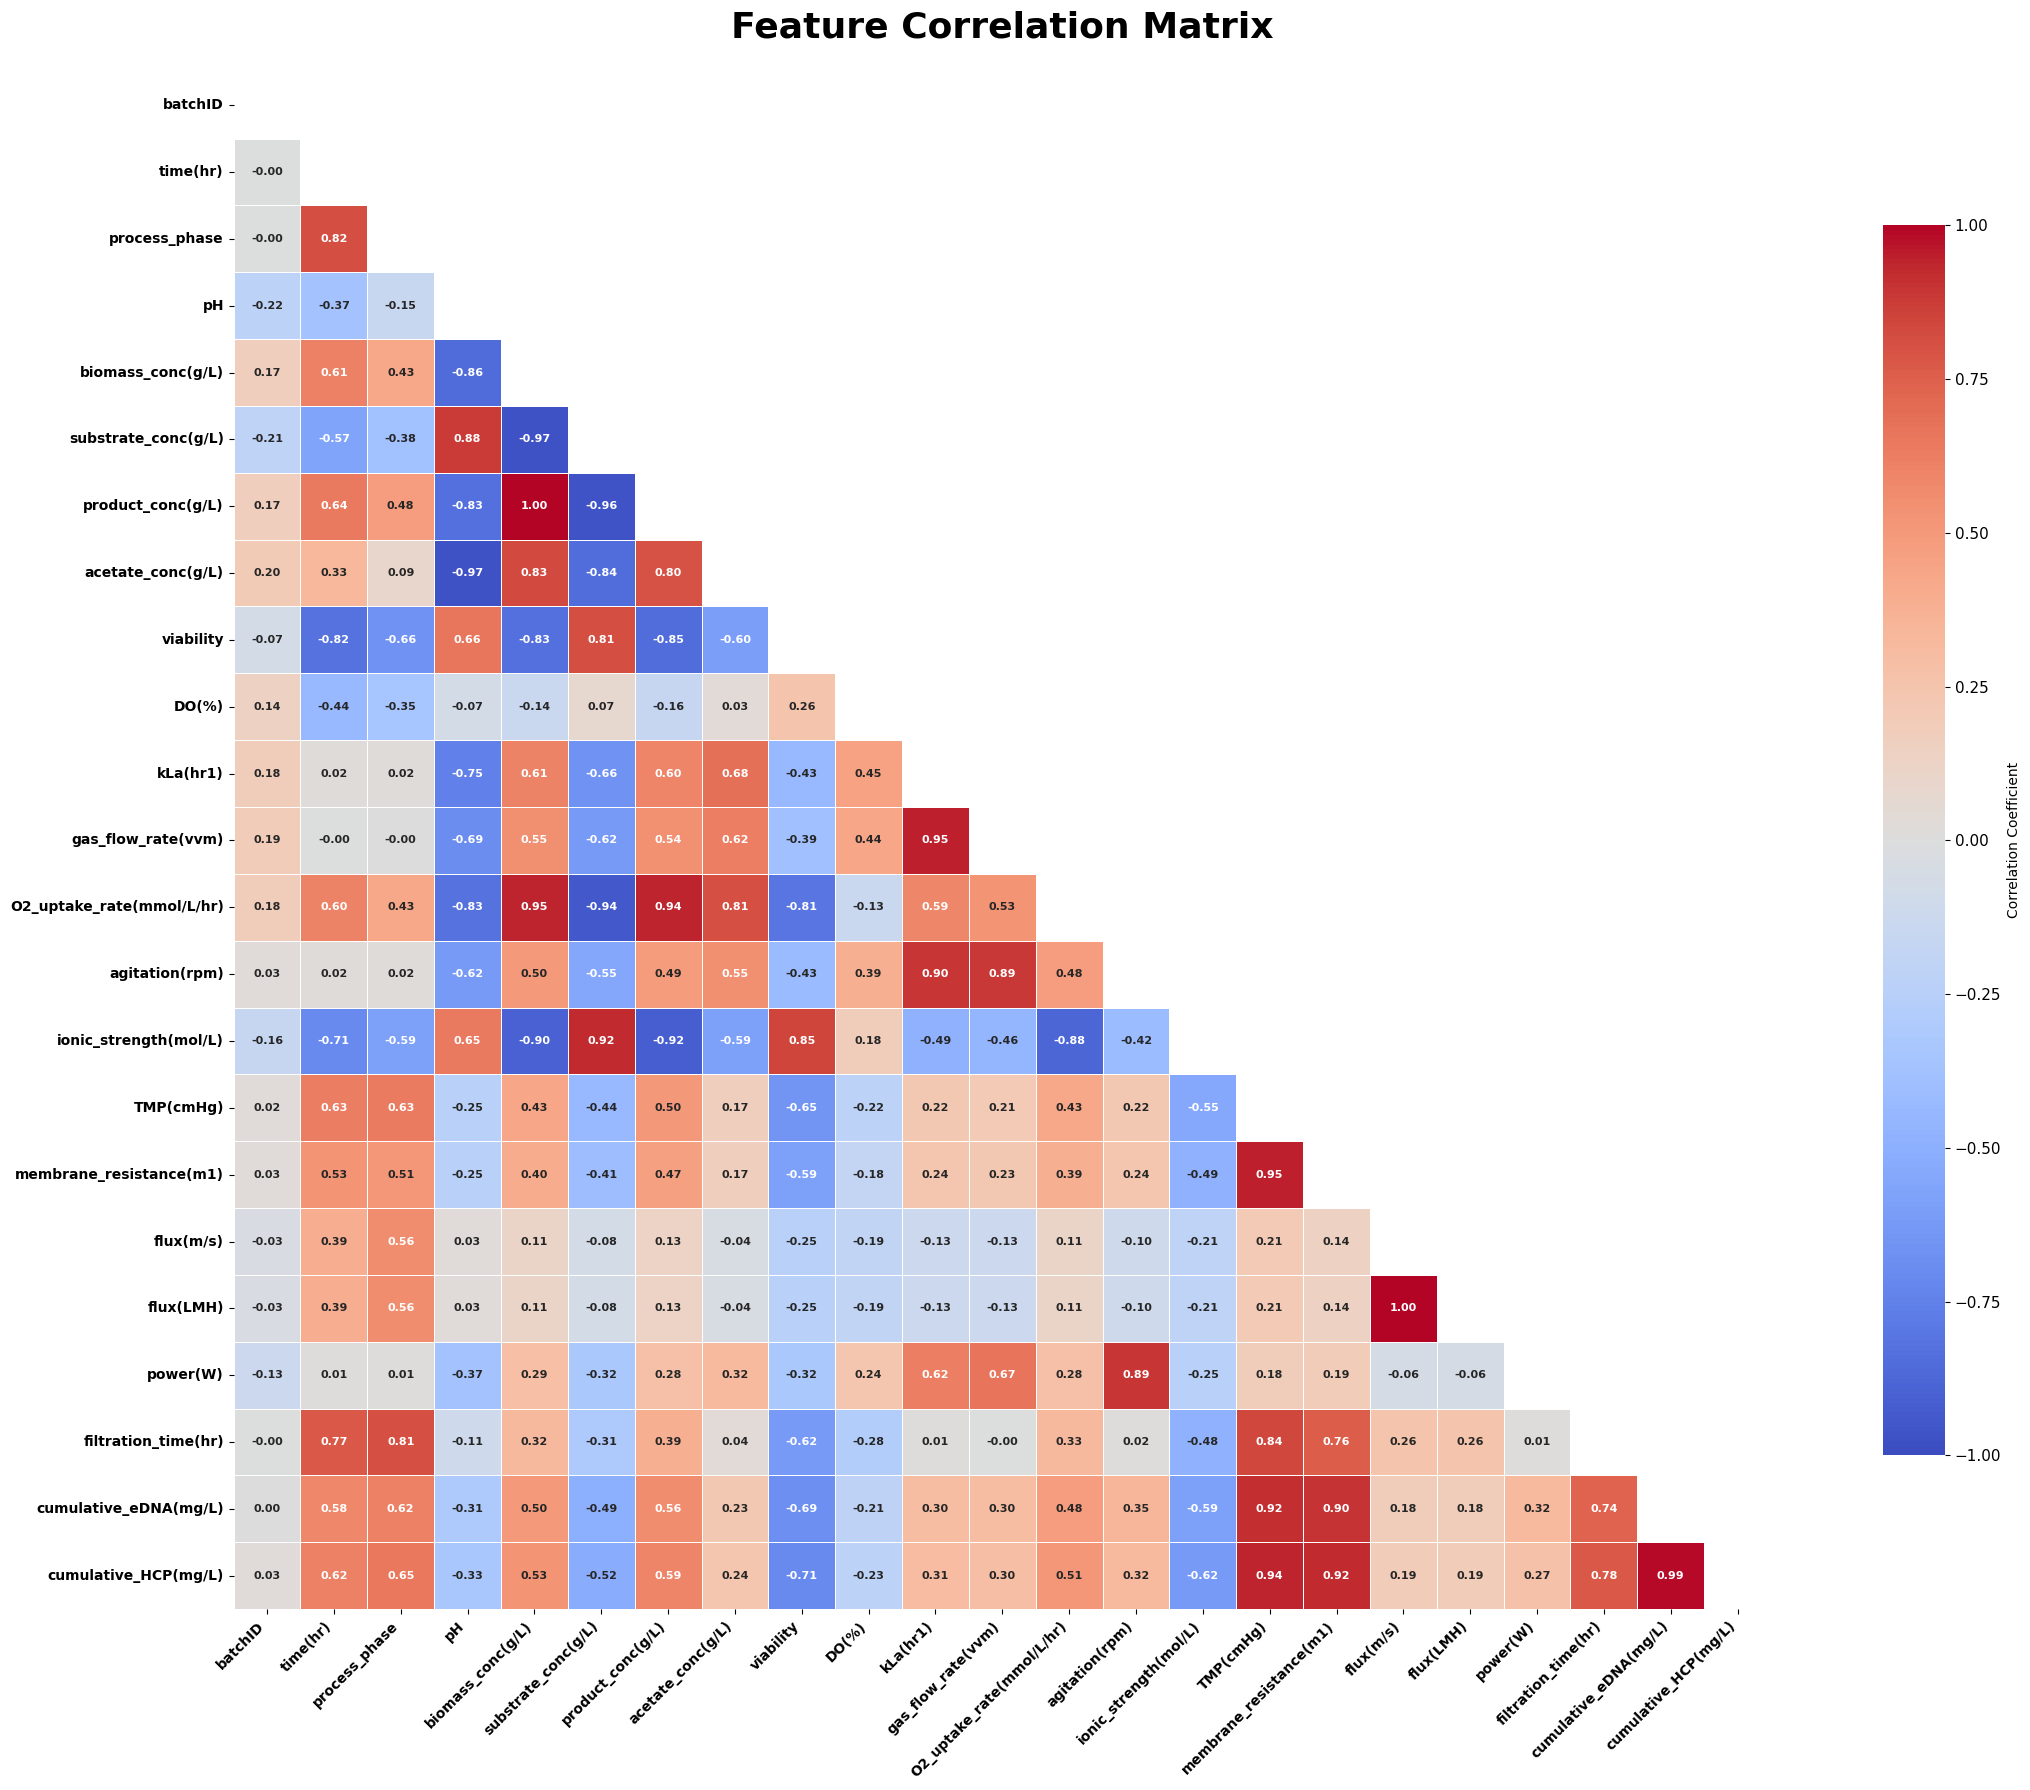

In [23]:
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)


plt.figure(
    figsize=(24,18),
    facecolor='white'
)

heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={
        "size":8,
        "weight":"bold"
    },
    linewidths=0.5,
    square=True,
    cbar_kws={
        "shrink":0.8,
        "label":"Correlation Coefficient"
    }
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=26,
    fontweight='bold',
    pad=25
)


plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    rotation=0,
    fontsize=10,
    fontweight='bold'
)


cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(
    labelsize=11
)


plt.tight_layout()
plt.show()

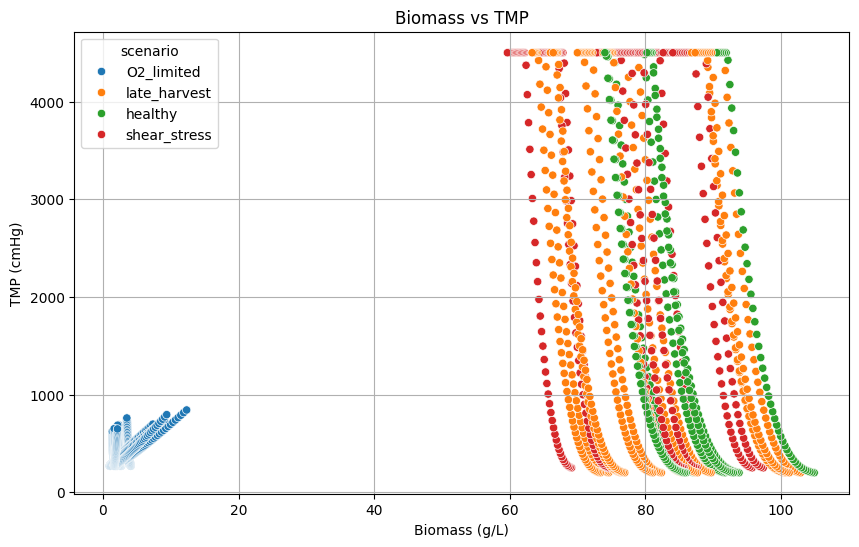

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=filtration_df,
    x='biomass_conc(g/L)',
    y='TMP(cmHg)',
    hue='scenario'
)

plt.title("Biomass vs TMP")
plt.xlabel("Biomass (g/L)")
plt.ylabel("TMP (cmHg)")
plt.grid(True)
plt.show()

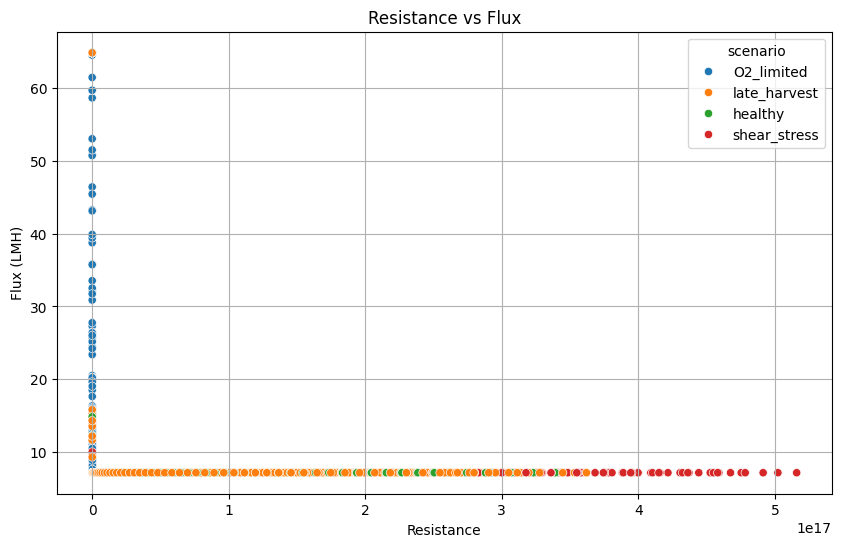

In [25]:
#flux vs membrane resistance
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=filtration_df,
    x='membrane_resistance(m1)',
    y='flux(LMH)',
    hue='scenario'
)

plt.title("Resistance vs Flux")
plt.xlabel("Resistance")
plt.ylabel("Flux (LMH)")
plt.grid(True)
plt.show()

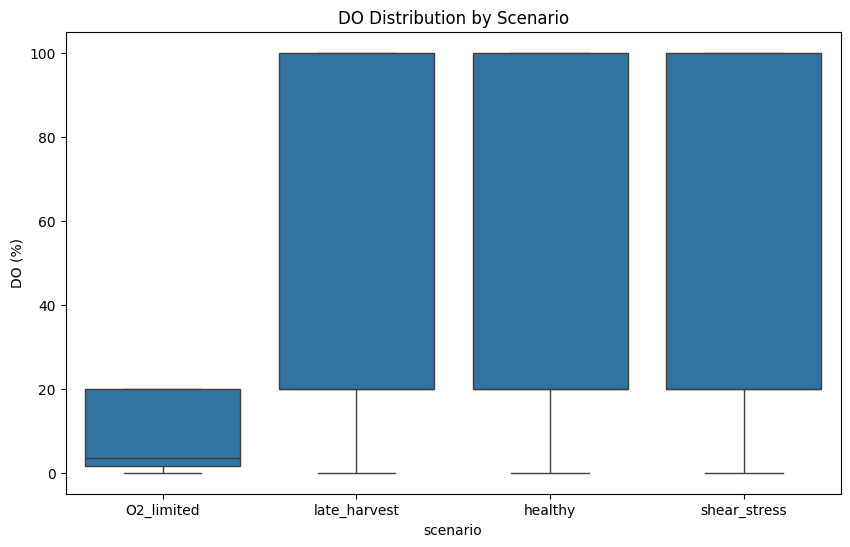

In [26]:
#oxygen limitation analysis
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='scenario',
    y='DO(%)'
)

plt.title("DO Distribution by Scenario")
plt.ylabel("DO (%)")
plt.show()


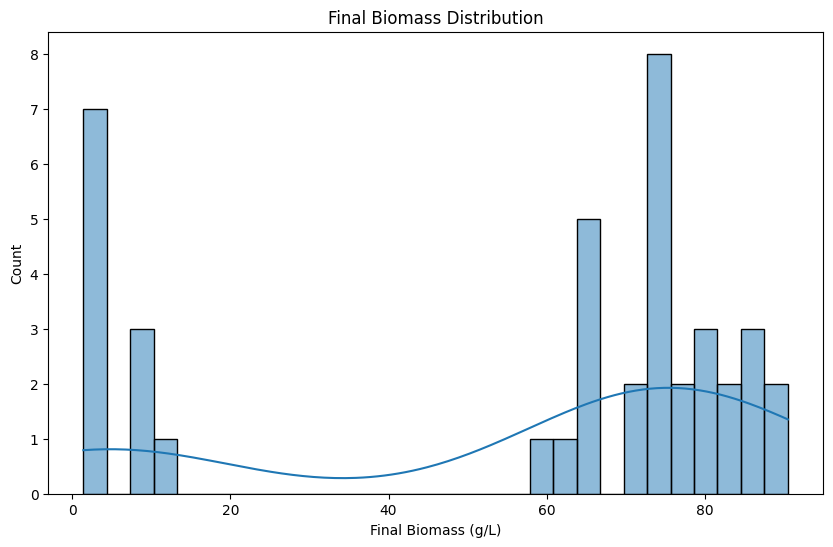


Mean Final Biomass:
56.03117869357129


In [27]:
#final biomass
final_points = (
    df.sort_values('time(hr)')
    .groupby('batchID')
    .tail(1)
)

plt.figure(figsize=(10,6))

sns.histplot(
    final_points['biomass_conc(g/L)'],
    bins=30,
    kde=True
)

plt.title("Final Biomass Distribution")
plt.xlabel("Final Biomass (g/L)")
plt.show()
print()
print("Mean Final Biomass:")
print(final_points['biomass_conc(g/L)'].mean())

In [28]:
summary = df.groupby('scenario')[[
    'biomass_conc(g/L)',
    'DO(%)',
    'flux(LMH)',
    'TMP(cmHg)',
    'viability',
    'power(W)'
]].mean()

display(summary)

,biomass_conc(g/L),DO(%),flux(LMH),TMP(cmHg),viability,power(W)
scenario,,,,,,
O2_limited,1.523802,8.210948,5.599093,146.034901,0.839858,0.807109
healthy,53.450726,52.713507,2.825238,522.753190,0.774311,67.031554
late_harvest,51.679120,51.960877,2.819288,612.371277,0.745853,80.012960
shear_stress,49.510835,52.560587,2.809116,834.377348,0.722143,417.472576
